<a href="https://colab.research.google.com/github/lcuenca1/Data201/blob/main/Week_5_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Resampling with Iris Dataset

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
print(len(iris))

150


In [3]:
print(iris.columns)

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')


### Part 1 --- Bootstrap Resampling

*Task 1*

In [5]:
mean_value = iris['sepal_length'].mean()
print(mean_value)

5.843333333333334


In [6]:
median_value = iris['sepal_length'].median()
print(median_value)

5.8


In [7]:
std_value = iris['sepal_length'].std()
print(std_value)

0.8280661279778629


*Task 2*

In [11]:
bootstrap_means = []

In [12]:
for i in range(5000):
    sample = iris['sepal_length'].sample(n=150, replace=True)
    mean_value = sample.mean()
    bootstrap_means.append(mean_value)

print(len(bootstrap_means))
print(bootstrap_means[:5])

5000
[np.float64(5.911333333333333), np.float64(5.936000000000001), np.float64(5.97), np.float64(5.804666666666667), np.float64(5.797333333333333)]


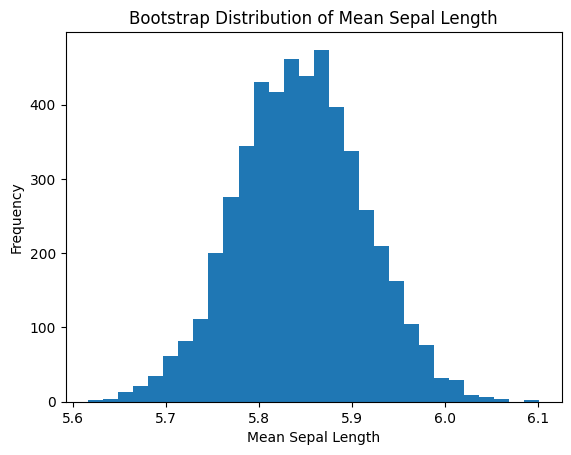

In [13]:
plt.hist(bootstrap_means, bins=30)
plt.xlabel("Mean Sepal Length")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of Mean Sepal Length")
plt.show()

The bootstrab distribution is mostly symetrical and centered around 5.85. This suggest that the sample mean is an estimate of the population mean.

*Task 3*

In [14]:
import numpy as np

In [17]:
bootstrap_mean = np.mean(bootstrap_means)
print(bootstrap_mean)

low = np.percentile(bootstrap_means, 2.5)
up = np.percentile(bootstrap_means, 97.5)

print("Lower bound:", low)
print("Upper bound:", up)

5.844619466666666
Lower bound: 5.71065
Upper bound: 5.976666666666667


Question  
Why is it mathematically necessary to sample with replacement in bootstrap resampling?  
It is important because it allow us to create new samples that are different from the original dataset. When we sample without replacement, every sample would be identical to the original dataset, with no posibility of measuring variability or estimate uncertainty.

### Part 2 --- Jacknife Resampling

In [20]:
jackknife_means = []

In [21]:
for i in range(len(iris)):
    jackknife_sample = iris['sepal_length'].drop(i)
    mean_value = jackknife_sample.mean()
    jackknife_means.append(mean_value)

print(len(jackknife_means))
print(jackknife_means[:5])

150
[np.float64(5.8483221476510066), np.float64(5.8496644295302005), np.float64(5.851006711409395), np.float64(5.851677852348993), np.float64(5.848993288590604)]


Question  
If the dataset contains n observations, exactly how many jackknife samples are created?  
Since the Iris dataset has 150 observations, exactly 150 jackknife samples are created.

### Part 3 --- Permutation Test  
  
*Task 5*

In [22]:
versicolor = iris[iris['species'] == 'versicolor']['sepal_length']
virginica = iris[iris['species'] == 'virginica']['sepal_length']

In [23]:
observed_diff = versicolor.mean() - virginica.mean()
print("Observed difference:", observed_diff)

Observed difference: -0.6519999999999984


*Task 6*

In [24]:
import numpy as np
combined = np.concatenate([versicolor.values, virginica.values])
n_versicolor = len(versicolor)
n_virginica = len(virginica)

In [25]:
permutation_diffs = []

for i in range(1000):
    # Shuffle the combined data
    np.random.shuffle(combined)

    perm_versicolor = combined[:n_versicolor]
    perm_virginica = combined[n_versicolor:]

    diff = perm_versicolor.mean() - perm_virginica.mean()
    permutation_diffs.append(diff)
print(len(permutation_diffs))
print(permutation_diffs[:5])


1000
[np.float64(0.08800000000000008), np.float64(-0.1120000000000001), np.float64(-0.036000000000000476), np.float64(-0.12399999999999789), np.float64(0.07599999999999874)]


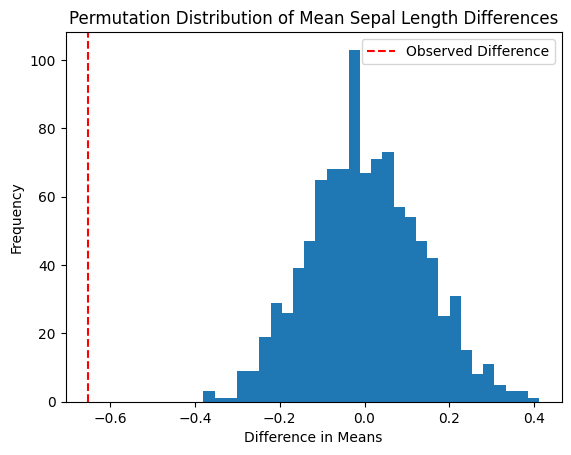

In [26]:
import matplotlib.pyplot as plt

plt.hist(permutation_diffs, bins=30)
plt.axvline(observed_diff, color='red', linestyle='dashed', label='Observed Difference')
plt.xlabel("Difference in Means")
plt.ylabel("Frequency")
plt.title("Permutation Distribution of Mean Sepal Length Differences")
plt.legend()
plt.show()

*Task 7: p-value*

In [27]:
count_extreme = sum(diff <= observed_diff for diff in permutation_diffs)

p_value = count_extreme / len(permutation_diffs)
print("p-value:", p_value)

p-value: 0.0


Questions  
What is the null hypothesis (H0) in this specific test?  
The null hypothesis is that there is no difference in the mean sepal lenght between the Versicolor and and Virginica species.  

  
What does the permutation distribution represent in terms of random chance?  
Shows the possible differences in means that could happen if the species labels were assigned randomly.  


Based on your p-value, do you reject or fail to reject the null hypothesis?  
We reject the null hypothesis, because my p-value is 0.0 which is lower than alpha.
